# Create a cool spider splot for the metrics

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D


## user defined functions

In [2]:
# Top-level transform that reads the number of variables from the axes instance.
class RadarTransform(PolarAxes.PolarTransform):
    def transform_path_non_affine(self, path):
        # get bound num_vars from the associated axes (safe fallback if missing)
        num_vars = getattr(getattr(self, "axes", None), "num_vars", 0)
        if path._interpolation_steps > 1 and num_vars:
            path = path.interpolated(num_vars)
        return Path(self.transform(path.vertices), path.codes)


class RadarAxes(PolarAxes):
    PolarTransform = RadarTransform

    def __init__(self, *args, **kwargs):
        # allow passing num_vars/frame via kwargs OR using class attributes set on a subclass
        self.num_vars = kwargs.pop(
            "num_vars", getattr(self.__class__, "num_vars", None)
        )
        self.frame = kwargs.pop("frame", getattr(self.__class__, "frame", "circle"))
        super().__init__(*args, **kwargs)
        self.set_theta_zero_location("N")

    def fill(self, *args, closed=True, **kwargs):
        return super().fill(closed=closed, *args, **kwargs)

    def plot(self, *args, **kwargs):
        lines = super().plot(*args, **kwargs)
        for line in lines:
            self._close_line(line)
        return lines

    def _close_line(self, line):
        x, y = line.get_data()
        if x.size and x[0] != x[-1]:
            x = np.append(x, x[0])
            y = np.append(y, y[0])
            line.set_data(x, y)

    def set_varlabels(self, labels, scriptsize=None):
        theta = np.linspace(0, 2 * np.pi, self.num_vars, endpoint=False)
        # set the angular tick labels; allow optional small font size via `scriptsize`
        self.set_thetagrids(np.degrees(theta), labels)
        if scriptsize is not None:
            for lbl in self.get_xticklabels():
                lbl.set_fontsize(scriptsize)

    def _gen_axes_patch(self):
        if self.frame == "circle":
            return Circle((0.5, 0.5), 0.5)
        elif self.frame == "polygon":
            return RegularPolygon((0.5, 0.5), self.num_vars, radius=0.5, edgecolor="k")
        else:
            msg = f"Unknown value for 'frame': {self.frame}"
            raise ValueError(msg)

    def _gen_axes_spines(self):
        if self.frame == "circle":
            return super()._gen_axes_spines()
        elif self.frame == "polygon":
            spine = Spine(
                axes=self,
                spine_type="circle",
                path=Path.unit_regular_polygon(self.num_vars),
            )
            spine.set_transform(
                Affine2D().scale(0.5).translate(0.5, 0.5) + self.transAxes
            )
            return {"polar": spine}
        else:
            raise ValueError("Unknown value for 'frame': %s" % self.frame)


def radar_factory(num_vars, frame="circle"):
    """
    Simplified factory.

    Compute theta, create/register a small subclass of RadarAxes
    bound to the requested num_vars/frame, and return theta.
    """
    theta = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)

    # create a tiny subclass to bind num_vars/frame as class attributes
    cls_name = f"RadarAxes_{num_vars}_{frame}"
    RadarAxesSub = type(
        cls_name,
        (RadarAxes,),
        {"name": "radar", "num_vars": num_vars, "frame": frame},
    )

    register_projection(RadarAxesSub)
    return theta


## data

In [3]:
def example_data():
    data = [
        ["MLP", "GB", "XGB", "RFR"],
        (
            "R²",
            [[0.9688, 0.9917, 0.9943, 0.9989], [0.9470, 0.9562, 0.9580, 0.9505]],
        ),
        (
            "MSE",
            [[0.0519, 0.0138, 0.0094, 0.0019], [0.0886, 0.0732, 0.0702, 0.0828]],
        ),
        (
            "MAE",
            [[0.1686, 0.0905, 0.0694, 0.0295], [0.2099, 0.1865, 0.1799, 0.1940]],
        ),
        (
            "RMSE",
            [[0.2279, 0.1173, 0.0972, 0.0432], [0.2976, 0.2706, 0.2650, 0.2878]],
        ),
    ]
    return data

## plot

['MLP', 'GB', 'XGB', 'RFR']


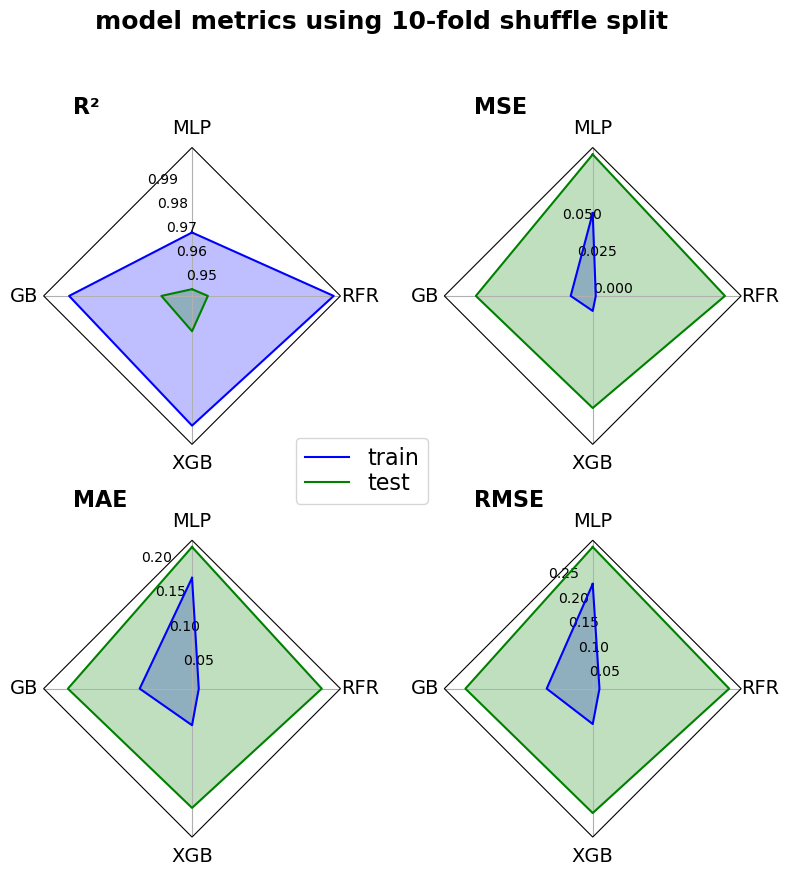

In [7]:
if __name__ == "__main__":
    N = 4
    theta = radar_factory(N, frame="polygon")

    # font size for the spoke (angular) labels
    varlabels_scriptsize = 14

    data = example_data()
    spoke_labels = data.pop(0)
    print(spoke_labels)

    fig, axs = plt.subplots(
        figsize=(9, 9), nrows=2, ncols=2, subplot_kw={"projection": "radar"}
    )
    fig.subplots_adjust(wspace=0.35, hspace=0.20, top=0.85, bottom=0.05)

    colors = ["b", "g"]
    # Plot the four cases from the example data on separate Axes
    for ax, (title, case_data) in zip(axs.flat, data, strict=False):
        if title == "R²":
            ax.set_rgrids([0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])
        if title == "MSE":
            ax.set_rgrids([0.0, 0.025, 0.05, 0.75, 0.10])
        if title == "MAE":
            ax.set_rgrids([0.0, 0.05, 0.10, 0.15, 0.20])
        if title == "RMSE":
            ax.set_rgrids([0.0, 0.05, 0.1, 0.15, 0.20, 0.25])
        ax.set_title(
            title,
            weight="bold",
            size=16,
            position=(0.1, 0.0),
            horizontalalignment="left",
            verticalalignment="center",
        )
        for d, color in zip(case_data, colors, strict=False):
            ax.plot(theta, d, color=color)
            ax.fill(theta, d, facecolor=color, alpha=0.25, label="_nolegend_")
        # pass scriptsize so spoke labels use the chosen small font
        ax.set_varlabels(spoke_labels, scriptsize=varlabels_scriptsize)

    # add legend relative to top-left plot
    labels = ("train", "test")
    legend = axs[0, 0].legend(labels, loc=(0.85, -0.2), labelspacing=0.1, fontsize=16)

    fig.text(
        0.5,
        0.965,
        "model metrics using 10-fold shuffle split",
        horizontalalignment="center",
        color="black",
        weight="bold",
        size=18,
    )

    plt.show()